In [5]:
# def block_jackknife(data, stat_func, B):
#     """
#     Block jackknife with B blocks
#     Returns: (theta_jackknife, standard_error)
#     """
#     n = len(data)
#     m = n // B
#     if m < 1:
#         print(f"  [block_jackknife] B={B}: m<1, skipping (n={n})")
#         return None

#     data = data[:m * B]
#     blocks = data.reshape(B, m)

#     theta_hat = stat_func(data)

#     thetas = np.array([
#         stat_func(np.concatenate([blocks[:i], blocks[i+1:]]).ravel())
#         for i in range(B)
#     ])
#     theta_bar = np.mean(thetas)

#     bias = (B - 1) * (theta_bar - theta_hat)
#     theta_jack = theta_hat - bias

#     var_dats = np.var(thetas, ddof=1)
#     mse = var_dats * (B - 1)**2 / B
#     se = np.sqrt(mse)

#     print(f"  [block_jackknife] B={B} | n={n} → trunc={m*B} | m(block_size)={m}")
#     print(f"    theta_hat  = {theta_hat:.6f}")
#     print(f"    thetas     = {np.round(thetas, 6)}")
#     print(f"    theta_bar  = {theta_bar:.6f}")
#     print(f"    bias       = {bias:.6f}")
#     print(f"    theta_jack = {theta_jack:.6f}")
#     print(f"    var_dats   = {var_dats:.6f}  (ddof=0)")
#     print(f"    se         = {se:.6f}")

#     return theta_hat, theta_jack, se

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


In [2]:
train = np.load("../data/c_a/processed/dataset_train_shortened.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]

full = np.load("../data/c_a/processed/dataset_full.npz", allow_pickle=True)
X_full  = full["X"]
K0_full = full["K0"]

In [3]:
def build_model(base_model, calibrated=False):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", base_model)
    ])
    if not calibrated:
        return pipe
    ##tego na dole nie robimy    
    if isinstance(base_model, LogisticRegression):
        return pipe
    return CalibratedClassifierCV(pipe, method="sigmoid", cv=3)


def run_supervised_pipeline(model, X_train, y_train, X_full):
    #trenujemy na 4.67 i 4.93
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)

    if hasattr(model, "predict_proba"):
        P_A = model.predict_proba(X_full)[:, 1]
    else:
        scores = model.decision_function(X_full)
        P_A = 1.0 / (1.0 + np.exp(-scores))

    return train_score, P_A



In [4]:
def stat_mean(x):
    return np.mean(x)

def stat_susceptibility(x):
    return np.var(x, ddof=1) / np.mean(x) ## ddof = 1 znaczy ze mamy n-1 w mianowniku

In [6]:
def block_jackknife(data, stat_func, B):
    """
    Block jackknife with B blocks
    Returns: (theta_jackknife, standard_error)
    """

    n = len(data)
    m = n // B  # block size -  zaokrąglenie do int

    if m < 1:
        return None


    # mathematica's (matches data[[1;;Quotient*B]]) -> python
    data = data[:m * B]
    
    # tak samo (matches Table[data[[...]], {i, 0, B-1}])
    blocks = data.reshape(B, m)
    
    # full estimator on data
    theta_hat = stat_func(data)

    # jeden blok out
    # dats = Table[stat(Flatten[data[[rands[[i]]]]]), {i, B}]
    thetas = np.array([
        stat_func(np.concatenate([blocks[:i], blocks[i+1:]]).ravel())
        for i in range(B)
    ])
    theta_bar = np.mean(thetas)

    # ---- bias (3.2.1) z jack.pdf
    bias = (B - 1) * (theta_bar - theta_hat)

    # ---- bias-corrected estimator
    theta_jack = theta_hat - bias

    # var = Variance[dats] * (B-1)^2 / B
    # Mathematica Variance = sample variance (ddof=1)
    var_dats = np.var(thetas, ddof=1)
    mse = var_dats * (B - 1)**2 / B
    se = np.sqrt(mse)
    
    return theta_hat, theta_jack, se           

In [7]:
# =============================================================================
# JACKKNIFE OVER K0 (MAX OVER BLOCKS)
# =============================================================================

def jackknife_over_K(
    P_A,
    K0,
    stat_func,
    B_range=range(2, 101),
):
    df = pd.DataFrame({"K0": K0, "P_A": P_A})
    results = {}

    for k, group in df.groupby("K0"):
        #dzieląc co 10 dostaje jeszcze mniejsjzy chi (susceptibility)
        # data = group["P_A"].values[::10]
        data = group["P_A"].values

        if len(data) < 2:
            continue

        # ---- central estimate (nie zależy od B)
        theta_hat = stat_func(data)
        se_max = -np.inf

        theta_jack_best = theta_hat  
        for B in B_range:
            # if k == 4.77: -> to było dla testów tylko
                out = block_jackknife(data, stat_func, B)
                if out is None:
                    continue
                _, theta_jack, se = out
                if se > se_max:
                    se_max = se
                    theta_jack_best = theta_jack  # track jack estimate at max-SE block
        
        results[k] = (theta_jack_best, se_max)
        
    K_vals = np.array(sorted(results.keys()))
    theta  = np.array([results[k][0] for k in K_vals])
    se     = np.array([results[k][1] for k in K_vals])

    return K_vals, theta, se


In [8]:
def error_vs_blocks_for_K(P_A, K0, target_K, stat_func, B_range=range(2,101)):
    mask = (K0 == target_K)
    print(mask)
    data = P_A[mask]

    B_vals = []
    errors = []

    for B in B_range:
        # if k == 4.77:
        out = block_jackknife(data, stat_func, B)
        if out is None:
                continue
    
        _, _, se = out

        B_vals.append(B)
        errors.append(se)

    return np.array(B_vals), np.array(errors)

In [9]:
# =============================================================================
# MAIN
# =============================================================================

models = {
    "Logistic Regression": LogisticRegression(),
}

curves = {}

for name, base_model in models.items():
    print(f"\n{'='*50}\nModel: {name}\n{'='*50}")
    curves[name] = {}

    for calibrated in [False]:
        label = "calibrated" if calibrated else "uncalibrated"
        model = build_model(base_model, calibrated=calibrated)

        t0 = time.perf_counter()
        train_score, P_A = run_supervised_pipeline(model, X_train, y_train, X_full)
        elapsed = time.perf_counter() - t0

        print(f"{label:12s} | train_acc={train_score:.4f} | time={elapsed:.2f}s")

        # ---- JACKKNIFE (MAX OVER BLOCKS)
        K_mean, mean_jack, mean_se  = jackknife_over_K(P_A, K0_full, stat_mean)
        K_chi,  chi_jack,  chi_se  = jackknife_over_K(P_A, K0_full, stat_susceptibility)

        print(len(K_mean), len(K_chi)) 
        
        curves[name][label] = {
            "K": K_mean,
            "mean": mean_jack,
            "mean_se": mean_se,
            "chi": chi_jack,
            "chi_se": chi_se,
        }


Model: Logistic Regression
uncalibrated | train_acc=1.0000 | time=1.74s
20 20


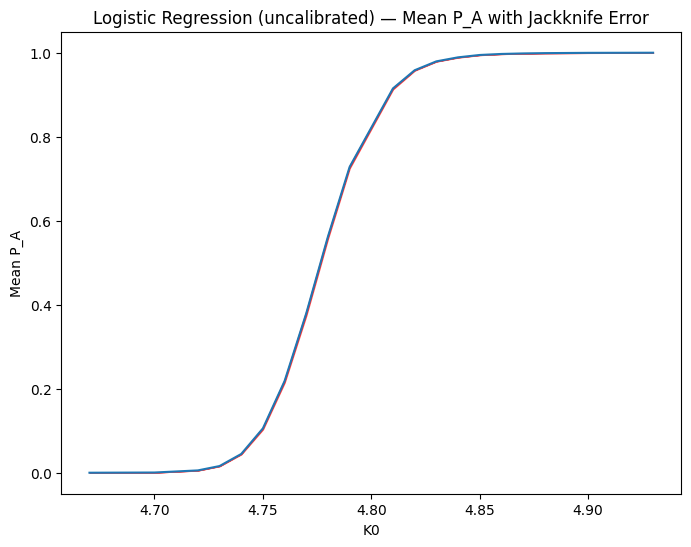

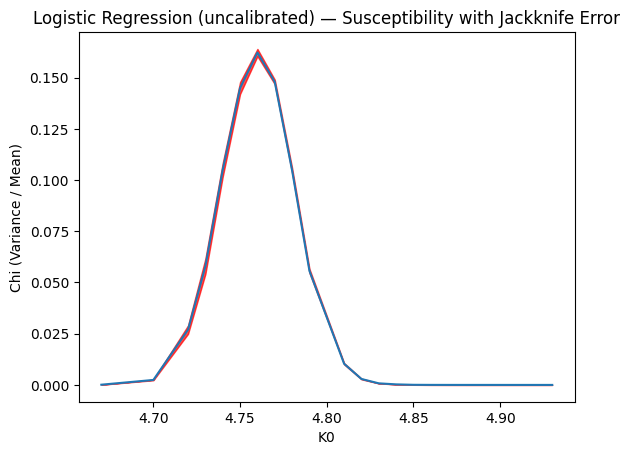

In [10]:
# =============================================================================
# PLOTTING
# =============================================================================

for name in curves:
    for label in curves[name]:
        data = curves[name][label]
        
        K = data["K"]

        plt.figure(figsize=(8, 6))
        plt.title(f"{name} ({label}) — Mean P_A with Jackknife Error")

        plt.plot(K, data["mean"])
        plt.fill_between(
            K,
            data["mean"] - data["mean_se"],
            data["mean"] + data["mean_se"],
            alpha=0.7,
            color="red"
        )

        plt.xlabel("K0")
        plt.ylabel("Mean P_A")

        # ---- SUSCEPTIBILITY
        plt.figure()
        plt.title(f"{name} ({label}) — Susceptibility with Jackknife Error")

        plt.plot(K, data["chi"])
        plt.fill_between(
            K,
            data["chi"] - data["chi_se"],
            data["chi"] + data["chi_se"],
            alpha=0.7,
            color="red"
      )

        plt.xlabel("K0")
        plt.ylabel("Chi (Variance / Mean)")

plt.show()

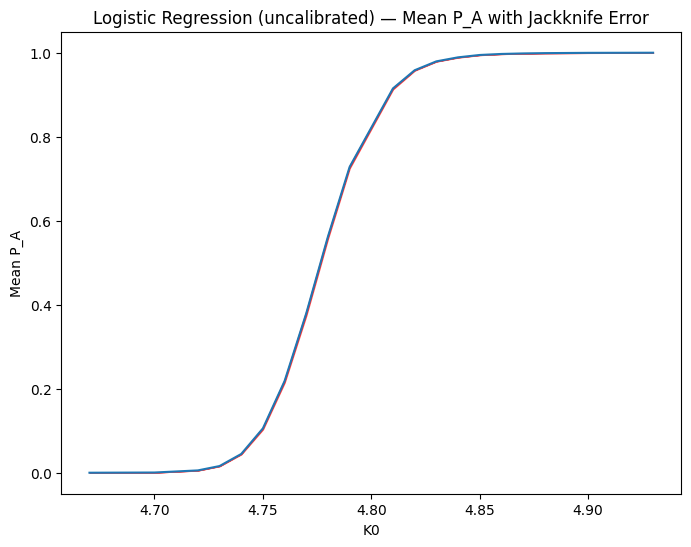

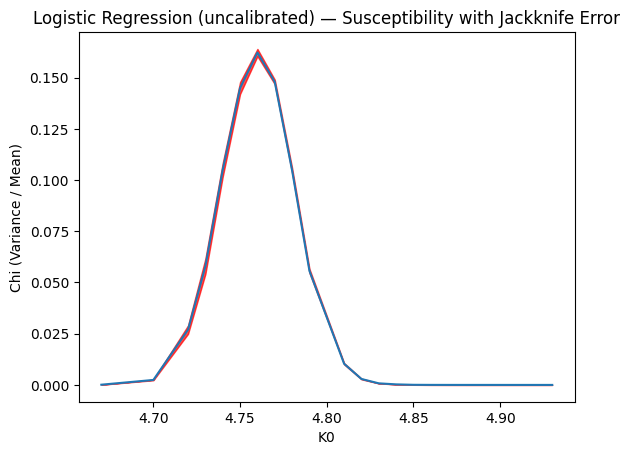

In [11]:
# =============================================================================
# PLOTTING
# =============================================================================

for name in curves:
    for label in curves[name]:
        data = curves[name][label]
        
        K = data["K"]

        plt.figure(figsize=(8, 6))
        plt.title(f"{name} ({label}) — Mean P_A with Jackknife Error")

        plt.plot(K, data["mean"])
        plt.fill_between(
            K,
            data["mean"] - data["mean_se"],
            data["mean"] + data["mean_se"],
            alpha=0.7,
            color="red"
        )

        plt.xlabel("K0")
        plt.ylabel("Mean P_A")

        # ---- SUSCEPTIBILITY
        plt.figure()
        plt.title(f"{name} ({label}) — Susceptibility with Jackknife Error")

        plt.plot(K, data["chi"])
        plt.fill_between(
            K,
            data["chi"] - data["chi_se"],
            data["chi"] + data["chi_se"],
            alpha=0.7,
            color="red"
      )

        plt.xlabel("K0")
        plt.ylabel("Chi (Variance / Mean)")

plt.show()

In [12]:
def jackknife_over_K_with_max_tracking(P_A, K0, stat_func, B_range=range(2, 101)):
    df = pd.DataFrame({"K0": K0, "P_A": P_A})
    results = {}

    for k, group in df.groupby("K0"):
        data = group["P_A"].values

        theta_hat = stat_func(data)   # central estimate, independent of B
        best_se = -np.inf
        theta_jack_best = theta_hat  # fallback
        for B in B_range:
            out = block_jackknife(data, stat_func, B)
            if out is None:
                continue
            _, theta_jack, se = out
            if se > best_se:
                best_se = se
                theta_jack_best = theta_jack
        
        results[k] = (theta_jack_best, best_se)

    K_vals = np.array(sorted(results.keys()))
    theta  = np.array([results[k][0] for k in K_vals])
    se     = np.array([results[k][1] for k in K_vals])
    return K_vals, theta, se    

Text(0.5, 1.0, 'Mean probability with max jackknife error')

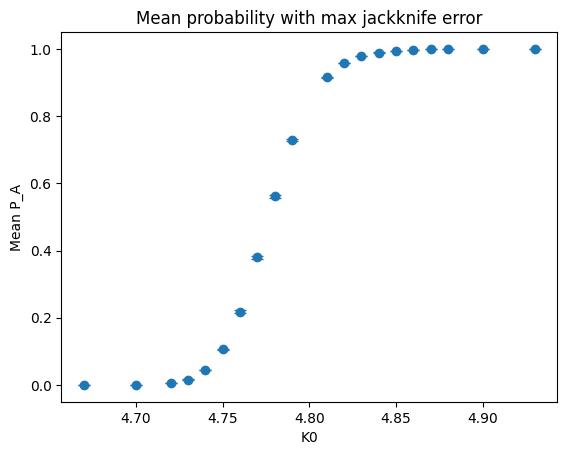

In [13]:
K, mean_jack, mean_se = jackknife_over_K_with_max_tracking(
    P_A, K0_full, stat_mean
)

plt.figure()
plt.errorbar(K, mean_jack, yerr=mean_se, fmt='o', capsize=4)
plt.xlabel("K0")
plt.ylabel("Mean P_A")
plt.title("Mean probability with max jackknife error")



Text(0.5, 1.0, 'Susceptibility with max jackknife error')

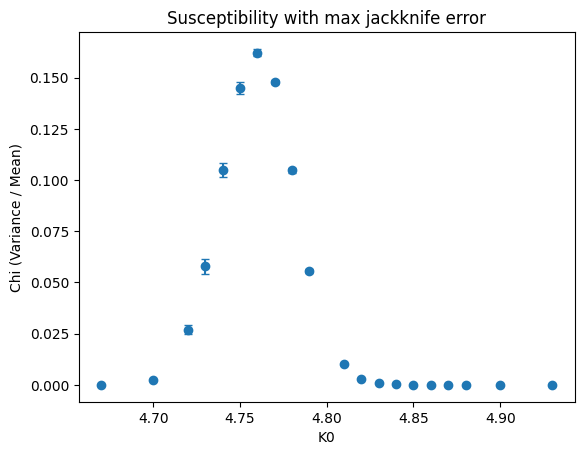

In [14]:
K, chi_jack, chi_se = jackknife_over_K_with_max_tracking(
    P_A, K0_full, stat_susceptibility
)

plt.figure()
plt.errorbar(K, chi_jack, yerr=chi_se, fmt='o', capsize=3)
plt.xlabel("K0")
plt.ylabel("Chi (Variance / Mean)")
plt.title("Susceptibility with max jackknife error")